# 模型训练

## 导入

In [1]:
import pickle as pkl
import dgl
from tqdm import tqdm
import random
import torch
from torch.utils.data.sampler import SubsetRandomSampler
from dgl.dataloading import GraphDataLoader
import torch.optim as optim
import numpy as np
import argparse
import os
import time

## 变量定义

In [ ]:
TIME = True

optimizer_name = "ADAM"
weight_decay = 5e-4
lr = 0.005

dataset_name = "wget"

device = "cpu"

num_hidden = 256
max_epoch = 5
num_layers = 4
negative_slope = 0.2 # leaky relu的负斜率
mask_rate = 0.5 # 掩码率
alpha_l = 3 # sce损失函数的幂次，a>1越大对错误样本惩罚越厉害，越小对错误样本越容忍（鲁棒性更高）

time_dim = 8

batch_size = 1

# 早停器
stopper_patience = 5 # 容忍轮数
stopper_min_delta = 0.01 # 最小改进幅度
stopper_threshold = 0.3 # 启动早停的最大loss

root_dir = '../../data'
networkx_graph_dir = '../../data/CICAPT_IIOT/networkx_graph/test-20-14/operation'
model_dir = "../checkpoints"
log_dir = "../logs/20-10"

## 数据加载

#### 从networkx图(graphs.pkl)读取原始数据

In [3]:
# 必须定义数据对象才能使用pkl进行反序列化
class WgetDataset(dgl.data.DGLDataset):
    def process(self):
        pass

    def __init__(self, name):
        super(WgetDataset, self).__init__(name=name)
        if name == "wget":
            path = final_data_dir

            num_graphs = sample_nums
            self.graphs = []
            self.labels = []
            print("Loading {} dataset...".format(name))
            for i in tqdm(range(num_graphs)):
                idx = i
                g = dgl.from_networkx(
                    nx.node_link_graph(
                        json.load(open("{}/{}.json".format(path, str(idx))))
                    ),
                    node_attrs=["type"],
                    edge_attrs=["type"],
                )
                self.graphs.append(g)
                if 0 <= idx < attack_nums:  # 恶意数据标为1
                    self.labels.append(1)
                else:  # 良性数据标为0
                    self.labels.append(0)
        else:
            raise NotImplementedError
    # 返回元组，第一个元素是dgl图，第二个元素是标签
    def __getitem__(self, i):
        return self.graphs[i], self.labels[i]

    def __len__(self):
        return len(self.graphs)

In [4]:
# 从pkl文件读取构建好的networkx图
def load_rawdata(name):
    path = networkx_graph_dir

    if os.path.exists(path + '/graphs.pkl'):
        print('Loading processed {} dataset...'.format(name))
        raw_data = pkl.load(open(path + '/graphs.pkl', 'rb'))
    else:
        raise FileNotFoundError(f"File {path}/graphs.pkl not found!")
    
    return raw_data

#### 提取特征维度，构建数据集

In [5]:
def load_batch_level_dataset(dataset_name):
    dataset = load_rawdata(dataset_name)
    graph, _ = dataset[0]
    node_feature_dim = 0
    for g, _ in dataset:
        node_feature_dim = max(node_feature_dim, g.ndata["type"].max().item()) # 结点特征维度：最大结点类型+1
    edge_feature_dim = 0
    for g, _ in dataset:
        edge_feature_dim = max(edge_feature_dim, g.edata["type"].max().item()) # 边特征维度：最大边类型+1
    node_feature_dim += 1
    edge_feature_dim += 1
    full_dataset = [i for i in range(len(dataset))]
    train_dataset = [i for i in range(len(dataset)) if dataset[i][1] == 0] # 训练数据全部是良性数据，学习正常模式
    print('[n_graph, n_node_feat, n_edge_feat]: [{}, {}, {}]'.format(len(dataset), node_feature_dim, edge_feature_dim))

    return {'dataset': dataset,
            'train_index': train_dataset,
            'full_index': full_dataset,
            'n_feat': node_feature_dim,
            'e_feat': edge_feature_dim}

#### 读取训练数据以及特征维度

In [10]:
dataset = load_batch_level_dataset("wget")
n_node_feat = dataset['n_feat']
n_edge_feat = dataset['e_feat']
graphs = dataset['dataset']
train_index = dataset['train_index']
n_dim = n_node_feat
e_dim = n_edge_feat

Loading processed wget dataset...
[n_graph, n_node_feat, n_edge_feat]: [34, 6, 13]


## 训练准备

#### 定义优化器

In [23]:
def create_optimizer(opt, model, lr, weight_decay):
    opt_lower = opt.lower()
    parameters = model.parameters()
    opt_args = dict(lr=lr, weight_decay=weight_decay)
    optimizer = None
    opt_split = opt_lower.split("_")
    opt_lower = opt_split[-1]
    if opt_lower == "adam":
        optimizer = optim.Adam(parameters, **opt_args)
    elif opt_lower == "adamw":
        optimizer = optim.AdamW(parameters, **opt_args)
    elif opt_lower == "adadelta":
        optimizer = optim.Adadelta(parameters, **opt_args)
    elif opt_lower == "radam":
        optimizer = optim.RAdam(parameters, **opt_args)
    elif opt_lower == "sgd":
        opt_args["momentum"] = 0.9
        return optim.SGD(parameters, **opt_args)
    else:
        assert False and "Invalid optimizer"
    return optimizer

#### 设置随机种子

In [24]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.determinstic = True

#### 构建模型

In [25]:
from model.my_model import MYModel

def build_model(args):
    num_hidden = args.num_hidden
    num_layers = args.num_layers
    negative_slope = args.negative_slope
    mask_rate = args.mask_rate
    alpha_l = args.alpha_l
    n_dim = args.n_dim
    e_dim = args.e_dim

    model = MYModel(
        n_dim=n_dim,
        e_dim=e_dim,
        hidden_dim=num_hidden,
        n_layers=num_layers,
        n_heads=4,
        activation="prelu",
        feat_drop=0.1,
        negative_slope=negative_slope,
        residual=True,
        mask_rate=mask_rate,
        norm='BatchNorm',
        loss_fn='sce',
        alpha_l=alpha_l
    )
    
    return model

#### 构建mini-batch数据

In [26]:
# 构建mini-batch，随机选择一部分数据训练
def extract_dataloaders(entries, batch_size):
    # 随机打乱数据索引顺序，确保训练数据的随机性
    random.shuffle(entries)
    
    # 创建0到len(entries)-1的连续索引张量
    train_idx = torch.arange(len(entries))
    
    # 创建随机采样器，用于从打乱后的索引中采样（一个epoch内不会重复）
    train_sampler = SubsetRandomSampler(train_idx)
    
    # 创建图数据加载器，用于批量加载图数据
    # 参数说明：
    # entries - 图数据条目
    # batch_size - 每批数据大小
    # sampler - 使用的采样器
    train_loader = GraphDataLoader(entries, batch_size=batch_size, sampler=train_sampler)
    return train_loader

#### 定义训练过程

In [27]:
from model.utils import transform_graph

def batch_level_train(
    model, # 模型
    graphs, # dgl图（训练数据）
    train_loader, # mini-batch数据加载器
    optimizer, # 优化器
    max_epoch, # 最大训练轮数
    device, # 设备
    n_dim=0, # 结点特征维度
    e_dim=0, # 边特征维度
    total_loss=None, # 总损失
    mean_loss=None, # epoch平均损失
    stopper=None, # 早停器
    log_path=None,  # 日志文件路径
):
    if log_path is not None:
        os.makedirs(os.path.dirname(log_path), exist_ok=True)
        log_file = open(log_path, 'w')
        log_file.write("Epoch\tIter\tLoss\n")
    else:
        log_file = None

    epoch_iter = tqdm(range(max_epoch))
    for epoch in epoch_iter:
        model.train()
        loss_list = []
        for iter, batch in enumerate(train_loader):
            batch_g = [
                transform_graph(graphs[idx][0], n_dim, e_dim).to(device)
                for idx in batch
            ]  # 将图的结点和边都转为特征向量
            batch_g = dgl.batch(batch_g)  # 将一个batch的图合并成一个图
            model.train()
            loss = model(batch_g)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_list.append(loss.item())
            total_loss.append(loss.item())

            if log_file is not None:
                log_file.write(f"{epoch}\t{iter}\t{loss.item():.6f}\n")

            del batch_g
            
        mean = np.mean(loss_list)
        mean_loss.append(mean)
        epoch_iter.set_description(
            f"Epoch {epoch} | train_loss: {mean:.4f}"  # ，，每个epoch的平均loss
        )

        if stopper.should_stop(mean):
            print(f"Early stopping at epoch {epoch}, best_loss: {stopper.best_loss:.4f}")
            break

    if log_file is not None:
        log_file.close()

    return model

In [28]:
from model.utils import transform_graph_with_time

def batch_level_train_with_time(
    model,  # 模型
    graphs,  # dgl图（训练数据）
    train_loader,  # mini-batch数据加载器
    optimizer,  # 优化器
    max_epoch,  # 最大训练轮数
    device,  # 设备
    n_dim=0,  # 结点特征维度
    e_dim=0,  # 边特征维度
    t_dim=0,  # 时间特征维度
    total_loss=None,  # 总损失
    mean_loss=None,  # epoch平均损失
    stopper=None,  # 早停器
    log_path=None,  # 日志文件路径
):
    if log_path is not None:
        os.makedirs(os.path.dirname(log_path), exist_ok=True)
        log_file = open(log_path, "w")
        log_file.write("Epoch\tIter\tLoss\n")
    else:
        log_file = None

    epoch_iter = tqdm(range(max_epoch))
    for epoch in epoch_iter:
        model.train()
        loss_list = []
        for iter, batch in enumerate(train_loader):
            batch_g = [
                transform_graph_with_time(graphs[idx][0], n_dim, e_dim, t_dim).to(
                    device
                )
                for idx in batch
            ]  # 将图的结点和边都转为特征向量
            batch_g = dgl.batch(batch_g)  # 将一个batch的图合并成一个图
            model.train()
            loss = model(batch_g)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_list.append(loss.item())
            total_loss.append(loss.item())

            if log_file is not None:
                log_file.write(f"{epoch}\t{iter}\t{loss.item():.6f}\n")

            del batch_g

        mean = np.mean(loss_list)
        mean_loss.append(mean)
        epoch_iter.set_description(
            f"Epoch {epoch} | train_loss: {mean:.4f}"  # ，，每个epoch的平均loss
        )

        if stopper.should_stop(mean):
            print(
                f"Early stopping at epoch {epoch}, best_loss: {stopper.best_loss:.4f}"
            )
            break

    if log_file is not None:
        log_file.close()

    return model

## 执行训练

In [ ]:
from model.utils import EarlyStopper

# 设置种子
set_random_seed(0)

# 损失和epoch平均损失
loss_list = []
mean_loss = []

# 早停器
early_stopper = EarlyStopper(
    patience=stopper_patience, min_delta=stopper_min_delta, threshold=stopper_threshold
)

# 日志文件地址
timestamp = str(int(time.time()))
log_file = os.path.join(log_dir, f"{dataset_name}-{timestamp}.log")

if TIME:
    model_args = argparse.Namespace(
        num_hidden=num_hidden,
        num_layers=num_layers,
        negative_slope=negative_slope,
        mask_rate=mask_rate,
        alpha_l=alpha_l,
        n_dim=n_dim,
        e_dim=e_dim + time_dim,
    )

    # 构建模型
    model = build_model(model_args)
    model = model.to(device)

    # 构建优化器
    optimizer = create_optimizer(optimizer_name, model, lr, weight_decay)

    # 训练
    model = batch_level_train_with_time(
        model,
        graphs,
        (extract_dataloaders(train_index, batch_size)),
        optimizer,
        max_epoch,
        device,
        n_dim=n_dim,
        e_dim=e_dim,
        t_dim=time_dim,
        total_loss=loss_list,
        mean_loss=mean_loss,
        stopper=early_stopper,
        log_path=log_file,
    )

    # 保存模型
    save_path = os.path.join(model_dir, f"t-checkpoint-{dataset_name}-{timestamp}.pt")
else:
    model_args = argparse.Namespace(
        num_hidden=num_hidden,
        num_layers=num_layers,
        negative_slope=negative_slope,
        mask_rate=mask_rate,
        alpha_l=alpha_l,
        n_dim=n_dim,
        e_dim=e_dim,
    )

    # 构建模型
    model = build_model(model_args)
    model = model.to(device)

    # 构建优化器
    optimizer = create_optimizer(optimizer_name, model, lr, weight_decay)

    # 训练
    model = batch_level_train(
        model,
        graphs,
        (extract_dataloaders(train_index, batch_size)),
        optimizer,
        max_epoch,
        device,
        n_dim=n_dim,
        e_dim=e_dim,
        total_loss=loss_list,
        mean_loss=mean_loss,
        stopper=early_stopper,
        log_path=log_file,
    )

    # 保存模型
    save_path = os.path.join(model_dir, f"checkpoint-{dataset_name}-{timestamp}.pt")

# 如果目录不存在，则创建
os.makedirs(model_dir, exist_ok=True)

torch.save(model.state_dict(), save_path)

Epoch 4 | train_loss: 0.2942: 100%|██████████| 5/5 [02:59<00:00, 35.88s/it]


## 结果可视化

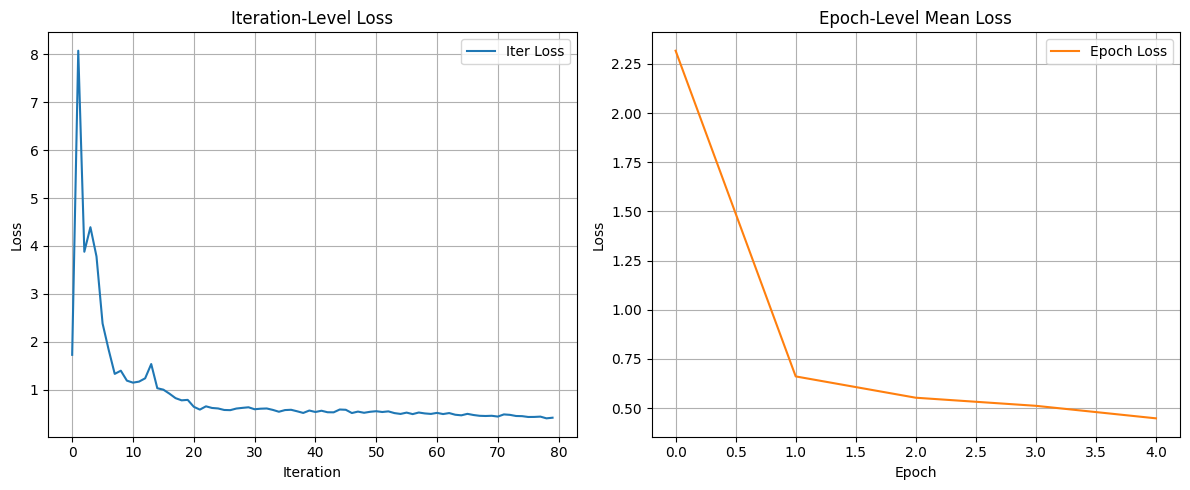

In [15]:
import matplotlib.pyplot as plt

# 创建画布和两个子图（1行2列）
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 可以根据需要调整 figsize

# 第一个子图：绘制每次迭代的 loss_list
axs[0].plot(loss_list, label="Iter Loss", color='tab:blue')
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel("Loss")
axs[0].set_title("Iteration-Level Loss")
axs[0].legend()
axs[0].grid(True)

# 第二个子图：绘制每个 epoch 的 mean_loss
axs[1].plot(mean_loss, label="Epoch Loss", color='tab:orange')
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].set_title("Epoch-Level Mean Loss")
axs[1].legend()
axs[1].grid(True)

# 自动调整子图间距
plt.tight_layout()

# 保存图像
plt.savefig("train_loss_subplots.png")  # 可选

# 显示图像
plt.show()